In [ ]:
!pip install -q ultralytics nibabel monai pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 115.4 MB/s eta 0:00:00


In [ ]:
import os
import numpy as np
import nibabel as nib
from PIL import Image
import random

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
os.makedirs("/content/data", exist_ok=True)
os.makedirs("/content/yolo_dataset", exist_ok=True)

In [ ]:
!nvidia-smi

Tue Apr 21 14:18:56 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install -q monai

from monai.apps import download_and_extract

url = "https://msd-for-monai.s3-us-west-2.amazonaws.com/Task01_BrainTumour.tar"

download_and_extract(
    url,
    "/content/data",
    "/content/data"
)

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


2026-04-21 14:19:49,333 - WARNING - filepath=/content/data, which missing file extension. Auto-appending extension to: /content/data.tar


data.tar: 7.09GB [03:45, 33.7MB/s]                            

2026-04-21 14:23:35,322 - INFO - Downloaded: /content/data.tar
2026-04-21 14:23:35,323 - INFO - Expected md5 is None, skip md5 check for file /content/data.tar.
2026-04-21 14:23:35,324 - INFO - Writing into directory: /content/data.


In [ ]:
#verify data
import os
print(os.listdir("/content/data/Task01_BrainTumour"))

['dataset.json', '._imagesTr', '._labelsTr', 'labelsTr', '._imagesTs', 'imagesTr', '._dataset.json', 'imagesTs']


In [ ]:
import os
import numpy as np
import nibabel as nib
from PIL import Image
import random

# Paths
images_path = "/content/data/Task01_BrainTumour/imagesTr"
labels_path = "/content/data/Task01_BrainTumour/labelsTr"
output_path = "/content/yolo_dataset"

# Create output folders
for split in ["train", "val"]:
    os.makedirs(f"{output_path}/images/{split}", exist_ok=True)
    os.makedirs(f"{output_path}/labels/{split}", exist_ok=True)

# Filter valid files (REMOVE MAC JUNK FILES)
files = [
    f for f in os.listdir(images_path)
    if f.endswith(".nii.gz") and not f.startswith("._")
]

print("Total patients:", len(files))

# Patient-wise split (CRITICAL)
random.shuffle(files)
split_idx = int(0.8 * len(files))

train_files = files[:split_idx]
val_files   = files[split_idx:]

print("Train patients:", len(train_files))
print("Val patients:", len(val_files))

count = 0

def process(file_list, split):
    global count

    for f in file_list:
        try:
            img_path = os.path.join(images_path, f)
            lbl_path = os.path.join(labels_path, f)

            image = nib.load(img_path).get_fdata()
            label = nib.load(lbl_path).get_fdata()

            for i in range(20, image.shape[2] - 20):

                img_slice = image[:, :, i, 3]   # FLAIR channel
                mask_slice = label[:, :, i]

                # Skip empty slices
                if np.sum(mask_slice) == 0:
                    continue

                # Normalize image
                img_slice = (img_slice - img_slice.min()) / (img_slice.max() - img_slice.min() + 1e-8)
                img_slice = (img_slice * 255).astype("uint8")

                # Convert to 3-channel
                img_slice = np.stack([img_slice]*3, axis=-1)

                # Bounding box
                coords = np.where(mask_slice > 0)
                x_min, x_max = np.min(coords[1]), np.max(coords[1])
                y_min, y_max = np.min(coords[0]), np.max(coords[0])

                # Remove tiny boxes (noise)
                if (x_max - x_min) < 10 or (y_max - y_min) < 10:
                    continue

                # Save image
                img_out = f"{output_path}/images/{split}/{count}.png"
                Image.fromarray(img_slice).save(img_out)

                # YOLO label format
                h, w = mask_slice.shape
                x_center = ((x_min + x_max) / 2) / w
                y_center = ((y_min + y_max) / 2) / h
                width = (x_max - x_min) / w
                height = (y_max - y_min) / h

                lbl_out = f"{output_path}/labels/{split}/{count}.txt"
                with open(lbl_out, "w") as ftxt:
                    ftxt.write(f"0 {x_center} {y_center} {width} {height}")

                count += 1

        except Exception as e:
            print(f"Skipping {f} due to error:", e)


# Run conversion
process(train_files, "train")
process(val_files, "val")

print("✅ Total samples created:", count)

Total patients: 484
Train patients: 387
Val patients: 97
✅ Total samples created: 31190


In [ ]:
#verify Dataset
import os

train_count = len(os.listdir("/content/yolo_dataset/images/train"))
val_count   = len(os.listdir("/content/yolo_dataset/images/val"))

print("Train images:", train_count)
print("Val images:", val_count)

ratio = train_count / (train_count + val_count)
print("Train ratio:", ratio)

Train images: 25009
Val images: 6181
Train ratio: 0.8018275088169285


In [ ]:
yaml = """
path: /content/yolo_dataset
train: images/train
val: images/val

nc: 1
names: ['tumor']
"""

with open("/content/yolo_dataset.yaml", "w") as f:
    f.write(yaml)

print("✅ YAML created")

✅ YAML created


In [ ]:
!pip install -q ultralytics

In [ ]:
from ultralytics import YOLO
print("Ultralytics installed successfully")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics installed successfully


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")

model.train(
    data="/content/yolo_dataset.yaml",
    epochs=20,
    imgsz=256,
    batch=32,
    patience=6,
    lr0=0.005,
    project="/content/drive/MyDrive/yolo_runs",
    name="brats_exp1_baseline",
    exist_ok=True,
    seed=0,
    workers=2
)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=256, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=brats_exp1_baseline, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pa

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f51816d83b0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/yolo_runs/brats_exp1_baseline/weights/best.pt")

metrics = model.val()

print(metrics)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 730.5±242.2 MB/s, size: 17.3 KB)
val: Scanning /content/yolo_dataset/labels/val.cache... 6181 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 6181/6181 1.4Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 387/387 11.6it/s 33.5s
                   all       6181       6181      0.905      0.795      0.867      0.548
Speed: 0.2ms preprocess, 1.7ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to /usr/local/lib/python3.12/dist-packages/tests/tmp/runs/detect/val
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f517c597350>
curves: [

In [ ]:
results_dict = {
    "precision": float(metrics.box.p),
    "recall": float(metrics.box.r),
    "mAP50": float(metrics.box.map50),
    "mAP50_95": float(metrics.box.map)
}

print(results_dict)

{'precision': 0.9045748371418088, 'recall': 0.7945316291862158, 'mAP50': 0.8671134099505252, 'mAP50_95': 0.5479847983452041}


/tmp/ipykernel_598/3696815193.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "precision": float(metrics.box.p),
/tmp/ipykernel_598/3696815193.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "recall": float(metrics.box.r),


In [ ]:
import os
print(os.path.exists("/content/drive/MyDrive"))

True


In [ ]:
!ls /content/drive/MyDrive/yolo_runs

brats_exp1_baseline


In [ ]:
!ls /content/drive/MyDrive/yolo_runs/brats_exp1_baseline/weights

best.pt  last.pt


In [ ]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/yolo_runs/brats_exp1_baseline/weights/best.pt")

In [ ]:
import shutil

shutil.copy(
    "/content/drive/MyDrive/yolo_runs/brats_exp1_baseline/weights/best.pt",
    "/content/drive/MyDrive/final_model.pt"
)

'/content/drive/MyDrive/final_model.pt'

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/yolo_runs/brats_exp1_baseline/weights/best.pt")
model.val()

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 700.1±247.1 MB/s, size: 14.8 KB)
val: Scanning /content/yolo_dataset/labels/val.cache... 6181 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 6181/6181 1.7Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 387/387 11.6it/s 33.3s
                   all       6181       6181      0.905      0.795      0.867      0.548
Speed: 0.2ms preprocess, 1.7ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to /usr/local/lib/python3.12/dist-packages/tests/tmp/runs/detect/val-2


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f517c5ebf80>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 


image 1/1 /content/yolo_dataset/images/val/27401.png: 256x256 1 tumor, 6.9ms
Speed: 0.6ms preprocess, 6.9ms inference, 1.2ms postprocess per image at shape (1, 3, 256, 256)

image 1/1 /content/yolo_dataset/images/val/30407.png: 256x256 (no detections), 7.8ms
Speed: 0.6ms preprocess, 7.8ms inference, 0.6ms postprocess per image at shape (1, 3, 256, 256)

image 1/1 /content/yolo_dataset/images/val/30133.png: 256x256 1 tumor, 7.0ms
Speed: 0.7ms preprocess, 7.0ms inference, 1.1ms postprocess per image at shape (1, 3, 256, 256)

image 1/1 /content/yolo_dataset/images/val/26535.png: 256x256 1 tumor, 7.0ms
Speed: 1.1ms preprocess, 7.0ms inference, 1.2ms postprocess per image at shape (1, 3, 256, 256)


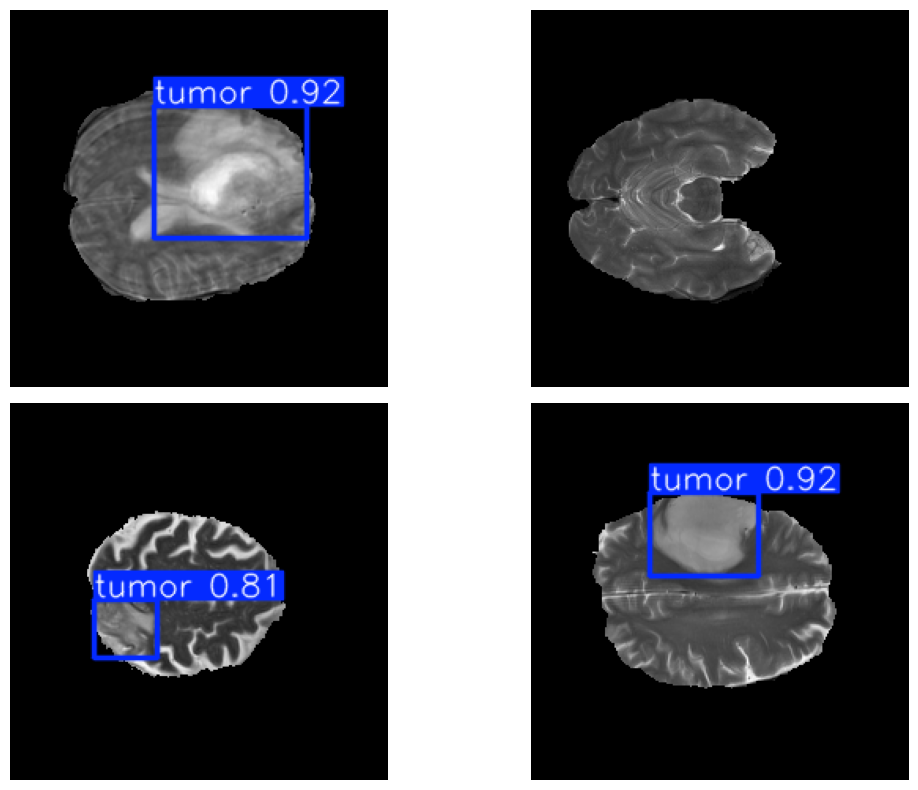

In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
import glob

model = YOLO("/content/drive/MyDrive/yolo_runs/brats_exp1_baseline/weights/best.pt")

images = glob.glob("/content/yolo_dataset/images/val/*.png")[:4]

plt.figure(figsize=(12,8))

for i, img_path in enumerate(images):
    results = model(img_path)
    img = results[0].plot()

    plt.subplot(2,2,i+1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')

plt.tight_layout()
plt.savefig("/content/figure1_detection.png", dpi=300)
plt.show()

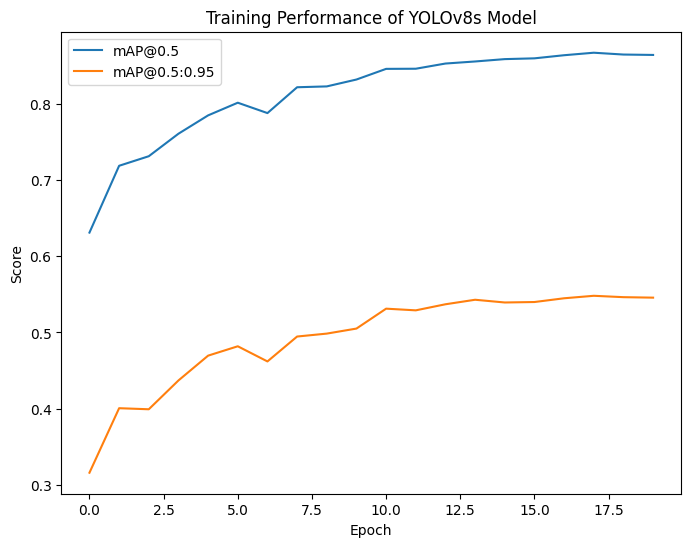

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/drive/MyDrive/yolo_runs/brats_exp1_baseline/results.csv")

plt.figure(figsize=(8,6))

plt.plot(df["metrics/mAP50(B)"], label="mAP@0.5")
plt.plot(df["metrics/mAP50-95(B)"], label="mAP@0.5:0.95")

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Training Performance of YOLOv8s Model")
plt.legend()

plt.savefig("/content/figure2_performance.png", dpi=300)
plt.show()

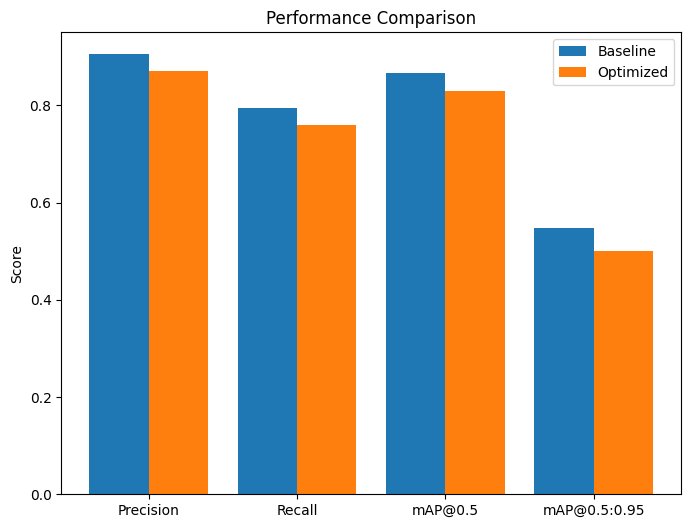

In [ ]:
import matplotlib.pyplot as plt

metrics = ["Precision", "Recall", "mAP@0.5", "mAP@0.5:0.95"]

baseline = [0.905, 0.795, 0.867, 0.548]
optimized = [0.87, 0.76, 0.83, 0.50]

x = range(len(metrics))

plt.figure(figsize=(8,6))
plt.bar(x, baseline, width=0.4, label="Baseline", align='center')
plt.bar([i+0.4 for i in x], optimized, width=0.4, label="Optimized")

plt.xticks([i+0.2 for i in x], metrics)
plt.ylabel("Score")
plt.title("Performance Comparison")

plt.legend()
plt.savefig("/content/figure3_comparison.png", dpi=300)
plt.show()

In [ ]:
from google.colab import files

files.download("/content/figure1_detection.png")
files.download("/content/figure2_performance.png")
files.download("/content/figure3_comparison.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


image 1/1 /content/yolo_dataset/images/val/27401.png: 256x256 1 tumor, 6.9ms
Speed: 0.8ms preprocess, 6.9ms inference, 1.1ms postprocess per image at shape (1, 3, 256, 256)

image 1/1 /content/yolo_dataset/images/val/30407.png: 256x256 (no detections), 8.1ms
Speed: 1.2ms preprocess, 8.1ms inference, 0.5ms postprocess per image at shape (1, 3, 256, 256)

image 1/1 /content/yolo_dataset/images/val/30133.png: 256x256 1 tumor, 6.9ms
Speed: 0.6ms preprocess, 6.9ms inference, 1.1ms postprocess per image at shape (1, 3, 256, 256)

image 1/1 /content/yolo_dataset/images/val/26535.png: 256x256 1 tumor, 6.9ms
Speed: 1.0ms preprocess, 6.9ms inference, 1.1ms postprocess per image at shape (1, 3, 256, 256)

image 1/1 /content/yolo_dataset/images/val/30695.png: 256x256 (no detections), 8.1ms
Speed: 0.8ms preprocess, 8.1ms inference, 0.5ms postprocess per image at shape (1, 3, 256, 256)

image 1/1 /content/yolo_dataset/images/val/28089.png: 256x256 1 tumor, 6.9ms
Speed: 0.8ms preprocess, 6.9ms infer

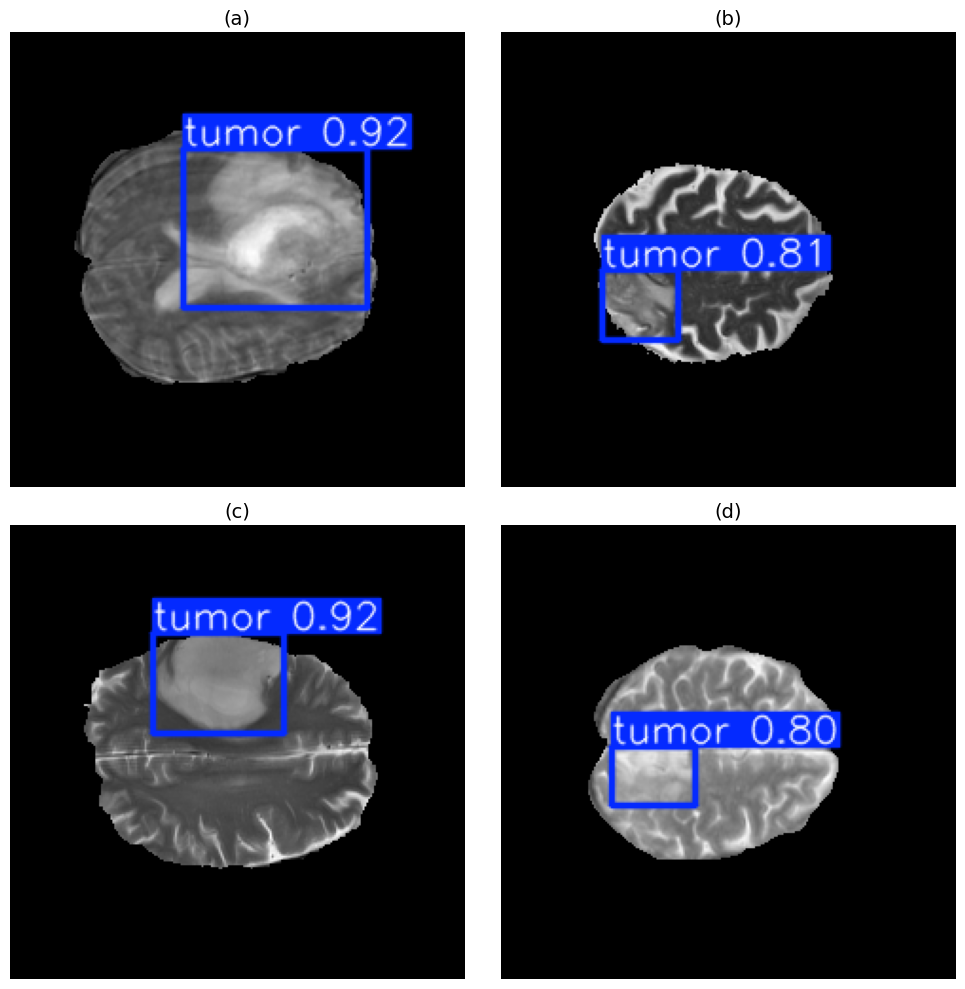

In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
import glob

# Load trained model
model = YOLO("/content/drive/MyDrive/yolo_runs/brats_exp1_baseline/weights/best.pt")

# Get validation images (pick more to filter good ones)
images = glob.glob("/content/yolo_dataset/images/val/*.png")

selected_images = []

# Select ONLY images where detection exists
for img_path in images:
    results = model(img_path)
    if len(results[0].boxes) > 0:  # ensure detection exists
        selected_images.append(img_path)
    if len(selected_images) == 4:
        break

# Plot figure
plt.figure(figsize=(10,10))

labels = ['(a)', '(b)', '(c)', '(d)']

for i, img_path in enumerate(selected_images):
    results = model(img_path)
    img = results[0].plot()

    plt.subplot(2,2,i+1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(labels[i], fontsize=14)
    plt.axis('off')

plt.tight_layout()
plt.savefig("/content/figure1_final.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
from google.colab import files
files.download("/content/figure1_final.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import shutil
shutil.copy(
    "/content/drive/MyDrive/yolo_runs/brats_exp1_baseline/weights/best.pt",
    "/content/drive/MyDrive/final_model.pt"
)

'/content/drive/MyDrive/final_model.pt'

In [ ]:
import json
json.dump(results_dict, open("/content/drive/MyDrive/final_results.json","w"))

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
import os
print(os.listdir("/content/drive/MyDrive"))

['Question Bank__RS_IV-I_B.Tech_Mid_I_(R20)_22jr batch.doc', 'Classroom', 'Kindey Stone Dataset.rar', 'Kindey Stone Dataset', 'Colab Notebooks', 'Kidney Stone.ipynb', 'yolo_dataset', 'brats_full', 'BraTS2021_00495.tar', 'yolo_runs', 'final_model.pt', 'final_results.json', 'brain_tumor_project']


In [3]:
import os

base = "/content/drive/MyDrive/yolo_dataset"

for item in os.listdir(base):
    print(item)

images
labels


In [4]:
for root, dirs, files in os.walk(base):
    print("Folder:", root)
    print("Dirs:", dirs)
    print("Files:", files[:5])
    print("------")
    break

Folder: /content/drive/MyDrive/yolo_dataset
Dirs: ['images', 'labels']
Files: []
------


In [5]:
import os

base = "/content/drive/MyDrive/yolo_dataset"

print("Images folder:", os.listdir(f"{base}/images"))
print("Labels folder:", os.listdir(f"{base}/labels"))

Images folder: ['train', 'val']
Labels folder: ['train', 'val']


In [6]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file.endswith(".txt"):
            print(root)
            break

/content/drive/MyDrive/brain_tumor_project/labels_original


In [7]:
import os, shutil

SRC = "/content/drive/MyDrive/brain_tumor_project/labels_original"
DST_TRAIN = "/content/drive/MyDrive/yolo_dataset/labels/train"
DST_VAL   = "/content/drive/MyDrive/yolo_dataset/labels/val"

os.makedirs(DST_TRAIN, exist_ok=True)
os.makedirs(DST_VAL, exist_ok=True)

# get image names
img_train = os.listdir("/content/drive/MyDrive/yolo_dataset/images/train")
img_val   = os.listdir("/content/drive/MyDrive/yolo_dataset/images/val")

count = 0

# copy matching labels
for f in img_train:
    lbl = f.replace(".jpg", ".txt")
    src_path = os.path.join(SRC, lbl)
    if os.path.exists(src_path):
        shutil.copy(src_path, os.path.join(DST_TRAIN, lbl))
        count += 1

for f in img_val:
    lbl = f.replace(".jpg", ".txt")
    src_path = os.path.join(SRC, lbl)
    if os.path.exists(src_path):
        shutil.copy(src_path, os.path.join(DST_VAL, lbl))
        count += 1

print("✅ Labels copied:", count)

✅ Labels copied: 0


In [12]:
import os, shutil, random

BASE = "/content/drive/MyDrive/brain_tumor_project"

images = os.listdir(f"{BASE}/images")

random.shuffle(images)
split = int(0.8 * len(images))

train = images[:split]
val = images[split:]

# create folders
os.makedirs(f"{BASE}/dataset/images/train", exist_ok=True)
os.makedirs(f"{BASE}/dataset/images/val", exist_ok=True)
os.makedirs(f"{BASE}/dataset/labels/train", exist_ok=True)
os.makedirs(f"{BASE}/dataset/labels/val", exist_ok=True)

for f in train:
    shutil.copy(f"{BASE}/images/{f}", f"{BASE}/dataset/images/train/{f}")
    shutil.copy(f"{BASE}/labels_original/{f.replace('.jpg','.txt')}", f"{BASE}/dataset/labels/train/{f.replace('.jpg','.txt')}")

for f in val:
    shutil.copy(f"{BASE}/images/{f}", f"{BASE}/dataset/images/val/{f}")
    shutil.copy(f"{BASE}/labels_original/{f.replace('.jpg','.txt')}", f"{BASE}/dataset/labels/val/{f.replace('.jpg','.txt')}")

print("✅ Dataset prepared correctly")

✅ Dataset prepared correctly


In [13]:
BASE = "/content/drive/MyDrive/brain_tumor_project"

with open(f"{BASE}/dataset.yaml", "w") as f:
    f.write(f"""
path: {BASE}/dataset
train: images/train
val: images/val

nc: 1
names: ['tumor']
""")

In [14]:
!pip install ultralytics

!yolo task=detect mode=train model=yolov8s.pt \
data=/content/drive/MyDrive/brain_tumor_project/dataset.yaml \
epochs=5 imgsz=256

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/brain_tumor_project/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=256, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overl

STEP 1 — CREATE MODERATE LABELS

In [15]:
import os

BASE = "/content/drive/MyDrive/brain_tumor_project"

src = f"{BASE}/labels_original"
dst = f"{BASE}/labels_moderate"

os.makedirs(dst, exist_ok=True)

def shrink(line, factor=0.85):
    parts = line.strip().split()
    cls, x, y, w, h = parts
    return f"{cls} {x} {y} {float(w)*factor} {float(h)*factor}\n"

for f in os.listdir(src):
    with open(f"{src}/{f}") as file:
        lines = file.readlines()
    new = [shrink(l, 0.85) for l in lines]
    with open(f"{dst}/{f}", "w") as file:
        file.writelines(new)

print("✅ Moderate labels ready")

✅ Moderate labels ready


Tight labels

In [16]:
dst = f"{BASE}/labels_tight"
os.makedirs(dst, exist_ok=True)

for f in os.listdir(src):
    with open(f"{src}/{f}") as file:
        lines = file.readlines()
    new = [shrink(l, 0.70) for l in lines]
    with open(f"{dst}/{f}", "w") as file:
        file.writelines(new)

print("✅ Tight labels ready")

✅ Tight labels ready


EXPERIMENT  — BASELINE (ORIGINAL LABELS)

In [19]:
import os, shutil

BASE = "/content/drive/MyDrive/brain_tumor_project"

# remove broken labels
shutil.rmtree(f"{BASE}/dataset/labels", ignore_errors=True)

# recreate folders
os.makedirs(f"{BASE}/dataset/labels/train", exist_ok=True)
os.makedirs(f"{BASE}/dataset/labels/val", exist_ok=True)

# copy ORIGINAL labels correctly
for f in os.listdir(f"{BASE}/dataset/images/train"):
    lbl = f.replace(".jpg", ".txt")
    src = f"{BASE}/labels_original/{lbl}"
    dst = f"{BASE}/dataset/labels/train/{lbl}"

    if os.path.exists(src):
        shutil.copy(src, dst)

for f in os.listdir(f"{BASE}/dataset/images/val"):
    lbl = f.replace(".jpg", ".txt")
    src = f"{BASE}/labels_original/{lbl}"
    dst = f"{BASE}/dataset/labels/val/{lbl}"

    if os.path.exists(src):
        shutil.copy(src, dst)

print("✅ Baseline labels fixed")

✅ Baseline labels fixed


In [20]:
print("Train images:", len(os.listdir(f"{BASE}/dataset/images/train")))
print("Train labels:", len(os.listdir(f"{BASE}/dataset/labels/train")))
print("Val images:", len(os.listdir(f"{BASE}/dataset/images/val")))
print("Val labels:", len(os.listdir(f"{BASE}/dataset/labels/val")))

Train images: 131
Train labels: 131
Val images: 47
Val labels: 47


In [21]:
!yolo task=detect mode=train model=yolov8s.pt \
data=/content/drive/MyDrive/brain_tumor_project/dataset.yaml \
epochs=10 imgsz=256 name=baseline

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/brain_tumor_project/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=256, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=baseline-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, o

APPLY MODERATE LABELS

In [22]:
import os, shutil

BASE = "/content/drive/MyDrive/brain_tumor_project"

# remove current labels
shutil.rmtree(f"{BASE}/dataset/labels", ignore_errors=True)

# recreate folders
os.makedirs(f"{BASE}/dataset/labels/train", exist_ok=True)
os.makedirs(f"{BASE}/dataset/labels/val", exist_ok=True)

# copy MODERATE labels
for f in os.listdir(f"{BASE}/dataset/images/train"):
    lbl = f.replace(".jpg", ".txt")
    shutil.copy(f"{BASE}/labels_moderate/{lbl}", f"{BASE}/dataset/labels/train/{lbl}")

for f in os.listdir(f"{BASE}/dataset/images/val"):
    lbl = f.replace(".jpg", ".txt")
    shutil.copy(f"{BASE}/labels_moderate/{lbl}", f"{BASE}/dataset/labels/val/{lbl}")

print("✅ Moderate labels applied")

✅ Moderate labels applied


In [23]:
!yolo task=detect mode=train model=yolov8s.pt \
data=/content/drive/MyDrive/brain_tumor_project/dataset.yaml \
epochs=10 imgsz=256 name=moderate

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/brain_tumor_project/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=256, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=moderate, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, ove

APPLY TIGHT LABELS

In [24]:
import os, shutil

BASE = "/content/drive/MyDrive/brain_tumor_project"

shutil.rmtree(f"{BASE}/dataset/labels", ignore_errors=True)

os.makedirs(f"{BASE}/dataset/labels/train", exist_ok=True)
os.makedirs(f"{BASE}/dataset/labels/val", exist_ok=True)

for f in os.listdir(f"{BASE}/dataset/images/train"):
    lbl = f.replace(".jpg", ".txt")
    shutil.copy(f"{BASE}/labels_tight/{lbl}", f"{BASE}/dataset/labels/train/{lbl}")

for f in os.listdir(f"{BASE}/dataset/images/val"):
    lbl = f.replace(".jpg", ".txt")
    shutil.copy(f"{BASE}/labels_tight/{lbl}", f"{BASE}/dataset/labels/val/{lbl}")

print("✅ Tight labels applied")

✅ Tight labels applied


In [25]:
!yolo task=detect mode=train model=yolov8s.pt \
data=/content/drive/MyDrive/brain_tumor_project/dataset.yaml \
epochs=10 imgsz=256 name=tight

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/brain_tumor_project/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=256, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=tight, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overla

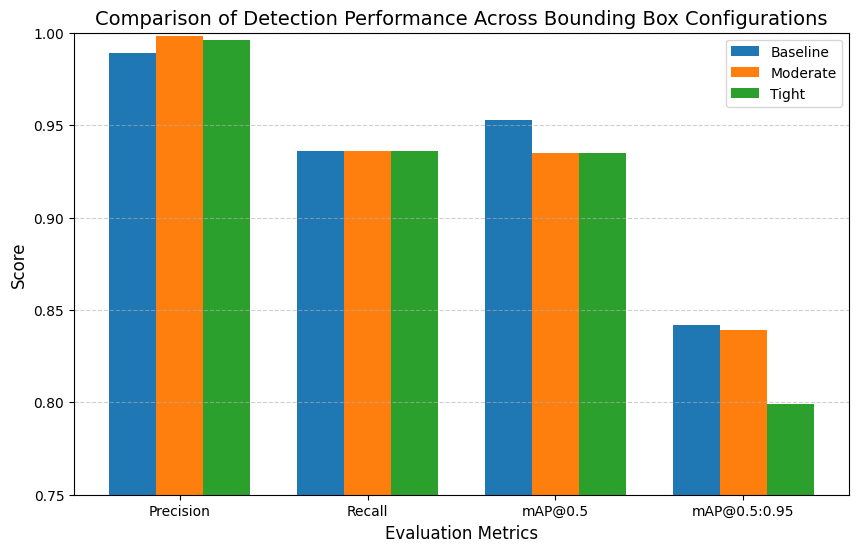

✅ Figure saved as /content/figure3.png


In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Data
metrics = ['Precision', 'Recall', 'mAP@0.5', 'mAP@0.5:0.95']

baseline = [0.989, 0.936, 0.953, 0.842]
moderate = [0.998, 0.936, 0.935, 0.839]
tight = [0.996, 0.936, 0.935, 0.799]

x = np.arange(len(metrics))
width = 0.25

# Plot
plt.figure(figsize=(10,6))

plt.bar(x - width, baseline, width, label='Baseline')
plt.bar(x, moderate, width, label='Moderate')
plt.bar(x + width, tight, width, label='Tight')

# Labels
plt.xlabel('Evaluation Metrics', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Comparison of Detection Performance Across Bounding Box Configurations', fontsize=14)

plt.xticks(x, metrics)
plt.ylim(0.75, 1.0)

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Save figure
plt.savefig('/content/figure3.png', dpi=300, bbox_inches='tight')

# Show
plt.show()

print("✅ Figure saved as /content/figure3.png")